# Rectangles vs Matérn fields, $N=2$ — like-for-like comparison of the two completed runs

In [1]:
import os, sys
import numpy as np
import torch
import matplotlib

if not os.environ.get('DISPLAY') and not hasattr(sys, 'ps1'):
    matplotlib.use('Agg')
import matplotlib.pyplot as plt

repo_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
data_dir  = os.path.join(repo_root, 'results', 'data')
fig_dir   = os.path.join(repo_root, 'results', 'figures')
os.makedirs(fig_dir, exist_ok=True)

RECT_C = [4, 8, 16, 32, 64, 128]
MAT_C  = [4, 8, 16, 32]
SHARED_C = [C for C in MAT_C if C in RECT_C]      # capacities present on both sides

def _load(p):
    if not os.path.exists(p):
        raise FileNotFoundError(
            f'{p}\nMissing artifact. The rectangles arms live on Killarney under '
            'results/data/baptista_rectangles_n2/ and must be rsynced before this runs.')
    return torch.load(p, map_location='cpu', weights_only=False)

RECT = {C: _load(os.path.join(data_dir, 'baptista_rectangles_n2', f'arm_c{C}_result.pt'))
        for C in RECT_C}
MAT  = {g: {C: _load(os.path.join(data_dir, 'baptista_matern_n2', f'arm_{g}_c{C}_result.pt'))
            for C in MAT_C}
        for g in ('rescaled', 'unit')}

n_expect = 50
for C, r in RECT.items():
    assert len(r['eval_log']) == n_expect, f'rect C={C}: {len(r["eval_log"])} evals, expected {n_expect}'
for g in MAT:
    for C, r in MAT[g].items():
        assert len(r['eval_log']) == n_expect, f'{g} C={C}: {len(r["eval_log"])} evals'
print(f'all {len(RECT) + sum(len(v) for v in MAT.values())} arms complete at {n_expect} evaluations each')


all 14 arms complete at 50 evaluations each


## Guard — the two runs really do share a pipeline

Asserts that everything outside the intended differences (data, `img_resolution`,
`attn_resolutions`, the metric, the geometry arm) is identical between the two runs.

In [2]:
SHOULD_MATCH = ['epochs', 'batch_mode', 'lr', 'lr_rampup_kimg', 'ema_halflife_kimg',
                'ema_rampup_ratio', 'P_mean', 'P_std', 'sigma_data', 'num_steps', 'sigma_min',
                'rho', 'S_churn', 'S_min', 'S_noise', 'n_eval_samples', 'eval_every',
                'seed', 'latent_seed']

rc, mc = RECT[4]['cfg'], MAT['rescaled'][4]['cfg']
bad = [(k, rc.get(k), mc.get(k)) for k in SHOULD_MATCH if rc.get(k) != mc.get(k)]
print(f"{'key':>20} {'rectangles':>14} {'matern':>14}")
for k in SHOULD_MATCH:
    flag = '' if rc.get(k) == mc.get(k) else '   <-- DIFFERS'
    print(f'{k:>20} {str(rc.get(k)):>14} {str(mc.get(k)):>14}{flag}')
assert not bad, f'pipeline drift between the two runs: {bad}'
print('\nevery shared pipeline setting is identical')

# sigma_max is per-geometry on the Matern side (top level of the result dict), inside cfg on the
# rectangles side.
def geom(r):
    d = r['data'].reshape(r['data'].shape[0], -1)
    D = torch.cdist(d, d)[0, 1].item()
    sigma_max = r.get('sigma_max', r['cfg'].get('sigma_max'))
    return D, sigma_max / D, float(r['data'].std())

print(f"\n{'run':>20} {'D_-':>10} {'smax/D_-':>10} {'std':>9} {'sigma_data/std':>15}")
for nm, r in [('rectangles', RECT[4]), ('matern rescaled', MAT['rescaled'][4]),
              ('matern unit', MAT['unit'][4])]:
    D, ratio, sd = geom(r)
    print(f'{nm:>20} {D:>10.4f} {ratio:>10.4f} {sd:>9.5f} {0.5 / sd:>15.3f}')
assert abs(geom(RECT[4])[0] - geom(MAT['rescaled'][4])[0]) < 1e-2, 'D_- not matched'
assert abs(geom(RECT[4])[1] - geom(MAT['rescaled'][4])[1]) < 1e-2, 'sigma_max/D_- not matched'
print('\nD_- and sigma_max/D_- match between rectangles and matern-rescaled')


                 key     rectangles         matern
              epochs          50000          50000
          batch_mode        main_py        main_py
                  lr          0.001          0.001
      lr_rampup_kimg          10000          10000
   ema_halflife_kimg            500            500
    ema_rampup_ratio           0.05           0.05
              P_mean           -1.2           -1.2
               P_std            1.2            1.2
          sigma_data            0.5            0.5
           num_steps             40             40
           sigma_min          0.002          0.002
                 rho              7              7
             S_churn            0.0            0.0
               S_min            0.0            0.0
             S_noise            1.0            1.0
      n_eval_samples            100            100
          eval_every           1000           1000
                seed              0              0
         latent_seed           

## The shared metric

$nn_{rel} = \min_k \|x_{gen} - x_k\|_2 \,/\, \operatorname{mean}_k \|x_k\|_2$ — scale-free and
defined identically for binary images and continuous fields. Panel (c) takes a median over the 16
stored samples per evaluation, not the 100 the published fractions used, so it is a different
estimator from panel (a).

In [3]:
def nn_rel_curve(r):
    '''Median nn_rel per evaluation, recomputed from the 16 stored samples.

    nn_rel = min_k ||x_gen - x_k|| / mean_k ||x_k||.  Scale-free, so it is defined the same way
    for binary rectangles and for Matern fields at any data scale.
    '''
    t = r['data'].reshape(r['data'].shape[0], -1)
    ep, med = [], []
    for e in r['eval_log']:
        s = e['samples'].reshape(e['samples'].shape[0], -1)
        v = torch.cdist(s, t).min(dim=1).values / t.norm(dim=1).mean()
        ep.append(e['epoch'])
        med.append(v.median().item())
    return np.array(ep), np.array(med)


def onset(ep, m, thresh):
    '''First epoch at which the curve drops below thresh, or None.'''
    return next((int(ep[i]) for i, v in enumerate(m) if v < thresh), None)


CURVES = {('rect', C): nn_rel_curve(RECT[C]) for C in RECT_C}
CURVES.update({(g, C): nn_rel_curve(MAT[g][C]) for g in MAT for C in MAT_C})
print('nn_rel recomputed for all arms from stored samples')


nn_rel recomputed for all arms from stored samples


## The figure

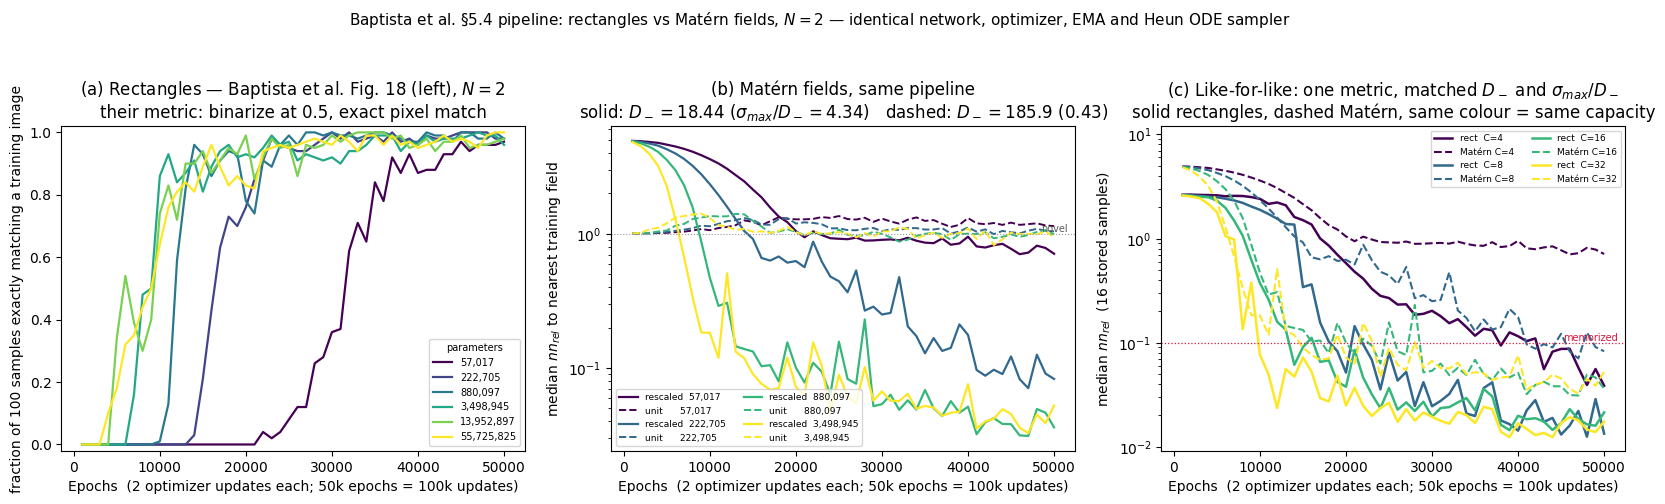

In [4]:
fig, ax = plt.subplots(figsize=(7.1, 4.5))
cm = plt.get_cmap('viridis')

# Matérn geometry comparison on the continuous metric.
for i, C in enumerate(MAT_C):
    c = cm(i / (len(MAT_C) - 1))
    e, m = CURVES[('rescaled', C)]
    ax.plot(e, m, color=c, lw=1.7, label=f"Rescaled, {MAT['rescaled'][C]['n_params']:,} parameters")
    e, m = CURVES[('unit', C)]
    ax.plot(e, m, color=c, lw=1.5, ls='--', label=f"Unit, {MAT['unit'][C]['n_params']:,} parameters")
ax.set_yscale('log')
ax.axhline(1.0, color='0.6', lw=0.8, ls=':')
ax.set_ylabel('Median relative distance')
ax.set_xlabel('Training epoch')
ax.set_title('SongUNet memorisation on Matérn fields')
ax.legend(fontsize=7, ncol=2, frameon=False)

plt.tight_layout()
plt.savefig(os.path.join(fig_dir, 'baptista_rect_vs_matern_n2.png'), dpi=150, bbox_inches='tight')
plt.show()


## Numbers

`onset` is the first epoch at which median $nn_{rel}$ drops below the threshold; the x-axis is
epochs, each of which is 2 optimizer updates.

In [5]:
print('Rectangles — reproduction of Figure 18 (their exact-match fraction over 100 samples)')
print(f"{'C':>5} {'params':>12} {'peak':>7} {'final':>7} {'first frac>=0.9':>16}")
for C in RECT_C:
    r = RECT[C]
    fr = [e['fraction'] for e in r['eval_log']]
    ep = [e['epoch'] for e in r['eval_log']]
    hit = next((ep[i] for i, v in enumerate(fr) if v >= 0.9), None)
    print(f"{C:>5} {r['n_params']:>12,} {max(fr):>7.2f} {fr[-1]:>7.2f} "
          f"{(f'{hit:,}' if hit else 'not reached'):>16}")
print("\nGATE: all six arms reach >=0.9  ->  reproduces 'all models transition to perfect "
      "memorization'")

print('\n\nLike-for-like, median nn_rel from the 16 stored samples, matched geometry')
print(f"{'C':>5} {'params':>12} | {'rect final':>11} {'Matérn final':>13} | "
      f"{'rect<0.1':>9} {'Matérn<0.1':>11} {'ratio':>7}")
for C in SHARED_C:
    er, mr = CURVES[('rect', C)]
    em, mm = CURVES[('rescaled', C)]
    o_r, o_m = onset(er, mr, 0.1), onset(em, mm, 0.1)
    ratio = f'{o_m / o_r:.2f}x' if (o_r and o_m) else '--'
    print(f"{C:>5} {RECT[C]['n_params']:>12,} | {mr[-1]:>11.4f} {mm[-1]:>13.4f} | "
          f"{str(o_r):>9} {str(o_m):>11} {ratio:>7}")

print('\n\nMatérn, unit geometry (sigma_max/D_- = 0.43) — none memorize')
print(f"{'C':>5} {'final nn_rel':>13} {'min nn_rel':>11}")
for C in MAT_C:
    e, m = CURVES[('unit', C)]
    print(f'{C:>5} {m[-1]:>13.4f} {m.min():>11.4f}')


Rectangles — reproduction of Figure 18 (their exact-match fraction over 100 samples)
    C       params    peak   final  first frac>=0.9
    4       57,017    0.97    0.97           37,000
    8      222,705    1.00    0.98           22,000
   16      880,097    1.00    0.98           14,000
   32    3,498,945    1.00    0.96           11,000
   64   13,952,897    1.00    0.98           15,000
  128   55,725,825    1.00    1.00           16,000

GATE: all six arms reach >=0.9  ->  reproduces 'all models transition to perfect memorization'


Like-for-like, median nn_rel from the 16 stored samples, matched geometry
    C       params |  rect final  Matérn final |  rect<0.1  Matérn<0.1   ratio
    4       57,017 |      0.0386        0.7096 |     38000        None      --
    8      222,705 |      0.0134        0.0827 |     19000       41000   2.16x
   16      880,097 |      0.0214        0.0361 |     14000       18000   1.29x
   32    3,498,945 |      0.0175        0.0525 |     10000     

## Reading

* All six rectangle arms reach a collapse fraction $\geq 0.9$, and onset falls with capacity across
  the bottom four sizes (37k → 22k → 14k → 11k epochs). C=64 and C=128 come in slightly later than
  C=32; their own Figure 18 curves also cross.
* At matched $D_-$ and $\sigma_{max}/D_-$, C=4 memorizes the rectangles (final $nn_{rel}$ 0.039) and
  does not memorize the fields (0.71). C=8, 16, 32 memorize both, with the fields lagging 1.3–2.2×
  in onset. The data shifts both the capacity threshold and the timing.
* The `unit` arm never memorizes and is not degenerate while failing to. Three ratios move together
  by ~10× between `unit` and `rescaled` — $\sigma_{max}/D_-$, $\sigma_{data}/\mathrm{std}$ and
  $P(\sigma_{train} > D_-/\sqrt2)$ — so this pair cannot say which is responsible.
* Not controlled: $\sigma_{data}/\mathrm{std}$ (2.51 / 4.79 / 0.475, not matchable while holding
  $D_-$), $d$ = 4096 vs 16384 under `main.py:84`'s `loss.sum()/B`, $32^2$ vs $16^2$ attention
  tokens, and a single seed (`seed=0`) everywhere.